In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.6 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requires pylibraft-cu12==24.12.*, but you have pylibraft-cu12 25.2.0 which is

In [2]:
import glob
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
classes = [0] * 4

files = glob.glob("/kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/train/labels/*.txt")
for txt_file_path in files:
    with open(txt_file_path) as f:
        strings = f.readlines()
        for string in strings:
            string = string.strip().split(" ")
            classes[int(string[0])] += 1
classes


[447, 603, 445, 662]

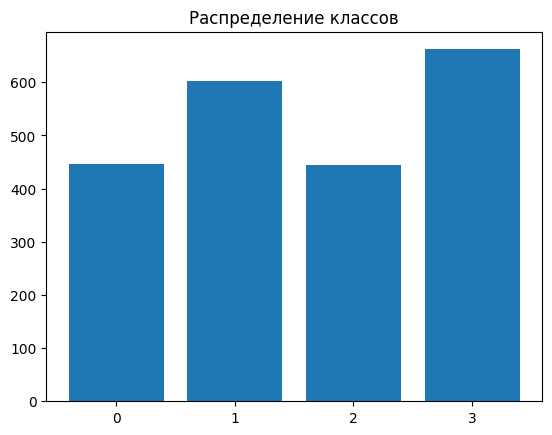

In [4]:
names = [str(idx) for idx in range(4)]
plt.bar(names, classes)
plt.title("Распределение классов")
plt.show()

In [5]:
data_yaml_path = "/kaggle/input/custom-yaml-2/dataset.yaml"

In [8]:
hyperparams_list = [
    {"lr0": 0.01, "momentum": 0.9,"optimizer":"Adam"},
    {"lr0": 0.001, "momentum": 0.95,"optimizer":"Adam", "hsv_h":0.03, "hsv_s":0.8, "hsv_v":0.5, 
     "degrees":30, "shear":5, "fliplr":0.9},
    {"lr0": 0.001, "momentum": 0.95, "optimizer":"Adam", "hsv_h":0.05, "hsv_s":0.9, "hsv_v":0.7, 
     "degrees":60, "translate":0.25, "shear":10, "fliplr":0.9, "erasing":0.8}
]
for params in hyperparams_list:
    model = YOLO("yolo11n.pt")
    result = model.train(data=data_yaml_path, epochs=50, **params)

Ultralytics 8.3.119 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/kaggle/input/custom-yaml-2/dataset.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=Tr

train: Scanning /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/train/labels... 1203 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1203/1203 [00:00<00:00, 1217.96it/s]

WARNING ⚠️ train: Cache directory /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/train is not writeable, cache not saved.


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 183.0±92.1 MB/s, size: 135.6 KB)


val: Scanning /kaggle/input/object-detection-wildlife-dataset-yolo-format/final_data/valid/labels... 150 images, 0 backgrounds, 0 corrupt: 100%|██████████| 150/150 [00:00<00:00, 1057.25it/s]

...


50 epochs completed in 0.240 hours.
Optimizer stripped from runs/detect/train4/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train4/weights/best.pt, 5.5MB

Validating runs/detect/train4/weights/best.pt...
Ultralytics 8.3.119 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  2.96it/s]


                   all        150        262      0.918      0.932      0.977      0.778
               buffalo         38         60      0.935       0.95      0.985      0.796
              elephant         43         83      0.909      0.904      0.968      0.751
                 rhino         42         58      0.959          1      0.994      0.861
                 zebra         28         61       0.87      0.876      0.963      0.705


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to runs/detect/train4


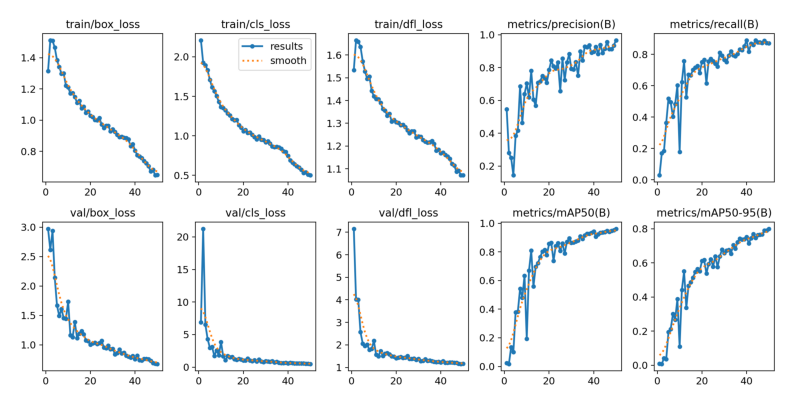

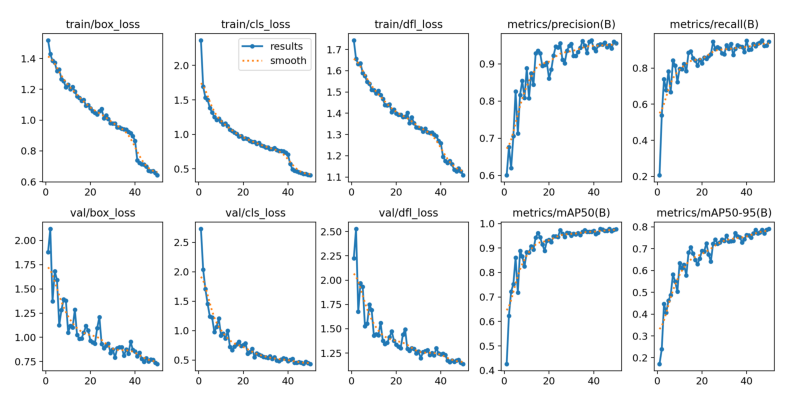

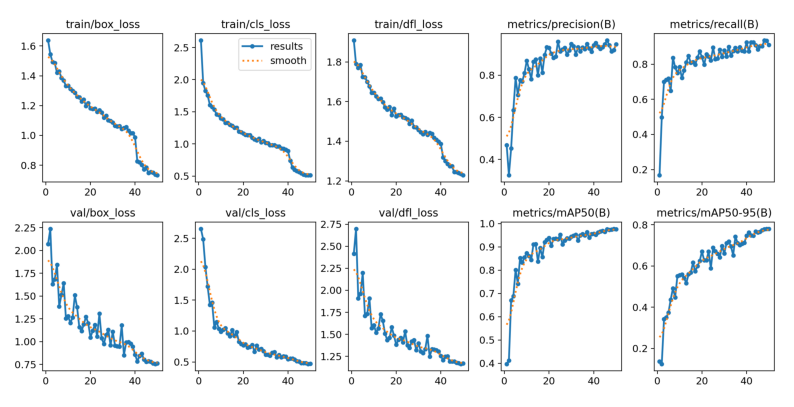

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

plot_paths = [
    "/kaggle/working/runs/detect/train2/results.png",
    "/kaggle/working/runs/detect/train3/results.png",
    "/kaggle/working/runs/detect/train4/results.png"
]

for path in plot_paths:
    img = Image.open(path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()